In [2]:
# ==========================
# Import Libraries
# ==========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


In [2]:
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

# Deep Learning
import tensorflow as tf

# Better plots
plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
# ==========================
# Load Dataset
# ==========================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Training Shape :", train.shape)
print("Testing Shape :", test.shape)

train.head()

Training Shape : (630000, 15)
Testing Shape : (270000, 14)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,54.136706,8.256301,29.0,48.00,54.0,60.00,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.00,1.0,1.00,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.00,4.0,4.00,4.0
BP,630000.0,130.497433,14.975802,94.0,120.00,130.0,140.00,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.00,243.0,269.00,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.00,0.0,0.00,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.00,0.0,2.00,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.00,157.0,166.00,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.00,0.0,1.00,1.0


In [7]:
train.head(10)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
5,5,38,1,4,138,283,0,0,147,1,1.6,2,2,7,Presence
6,6,59,1,4,130,246,0,2,152,0,0.8,2,2,3,Presence
7,7,60,0,3,120,245,0,0,151,0,1.2,1,0,3,Absence
8,8,48,0,4,140,212,0,2,125,0,0.0,1,0,3,Absence
9,9,44,0,4,150,197,0,0,150,0,0.0,2,0,3,Absence


In [8]:
print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape:", test.shape)

Training Dataset Shape: (630000, 15)
Testing Dataset Shape: (270000, 14)


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,630000.0,314999.500000,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,54.136706,8.256301,29.0,48.00,54.0,60.00,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.00,1.0,1.00,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.00,4.0,4.00,4.0
BP,630000.0,130.497433,14.975802,94.0,120.00,130.0,140.00,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.00,243.0,269.00,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.00,0.0,0.00,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.00,0.0,2.00,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.00,157.0,166.00,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.00,0.0,1.00,1.0


In [11]:
train.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [12]:
print("Duplicate rows:", train.duplicated().sum())

Duplicate rows: 0


In [13]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [14]:
train["Heart Disease"].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

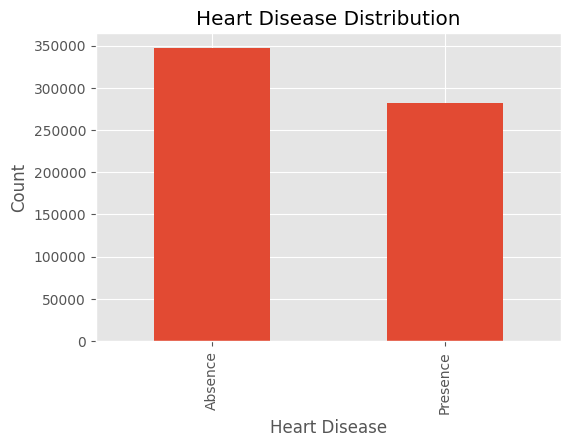

In [15]:
import matplotlib.pyplot as plt

train["Heart Disease"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Heart Disease Distribution"
)

plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

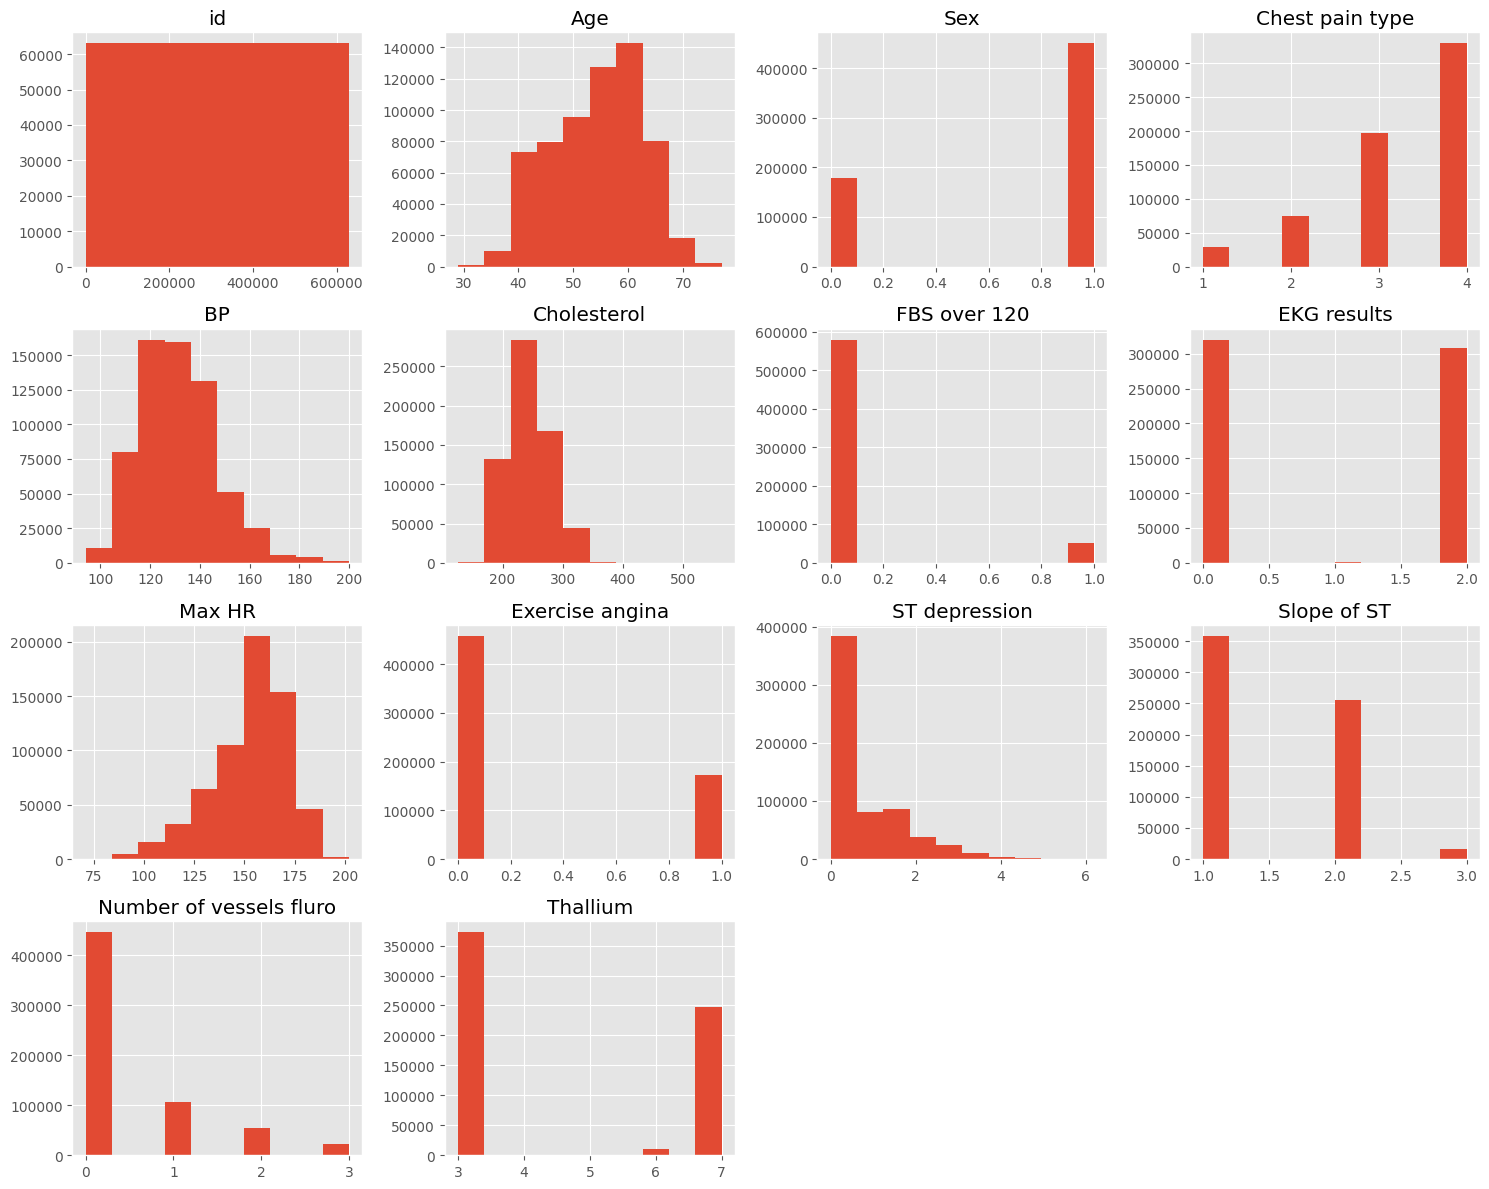

In [16]:
train.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

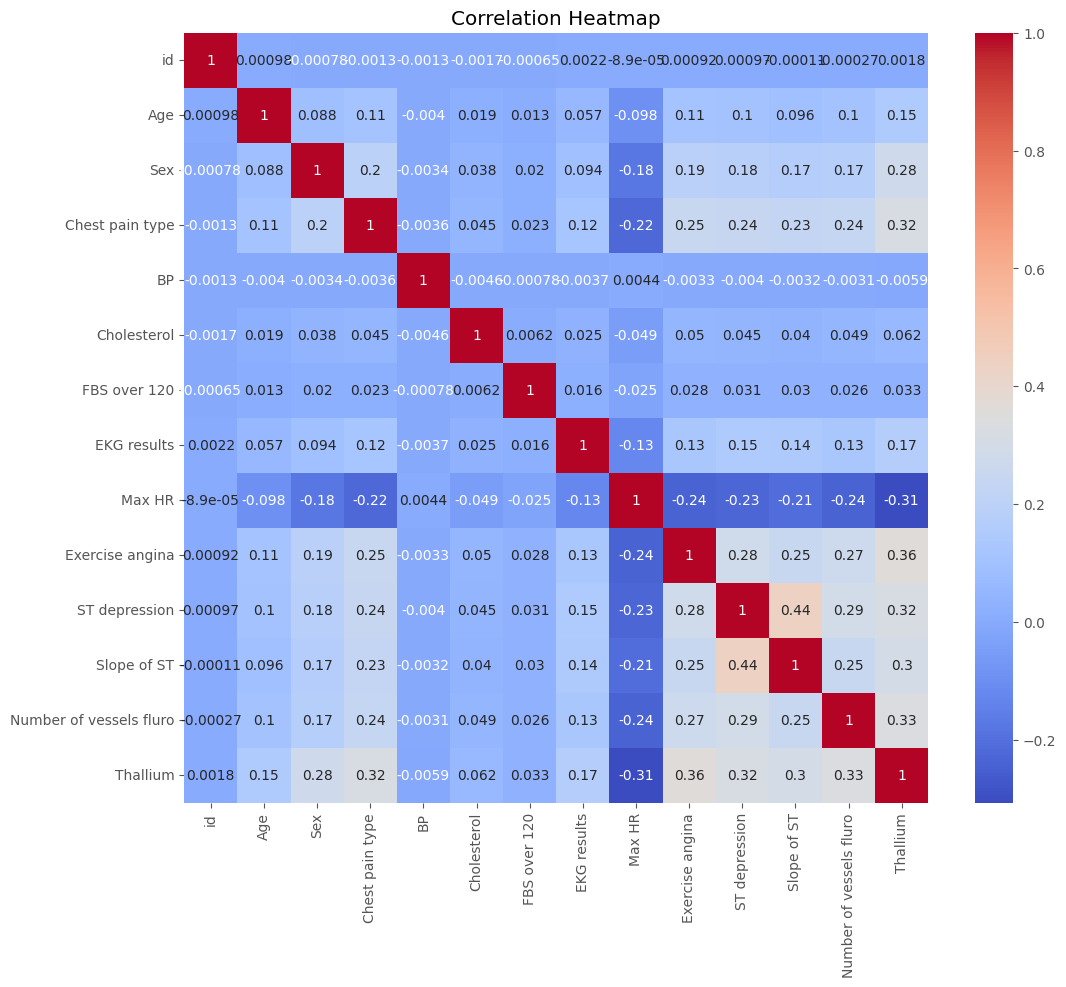

In [17]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(train.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

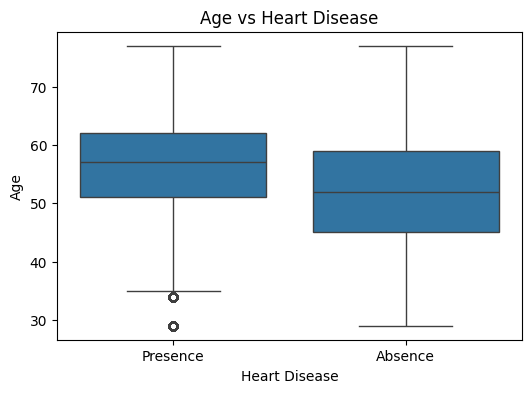

In [6]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(x='Heart Disease', y='Age', data=train)
plt.title('Age vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.show()

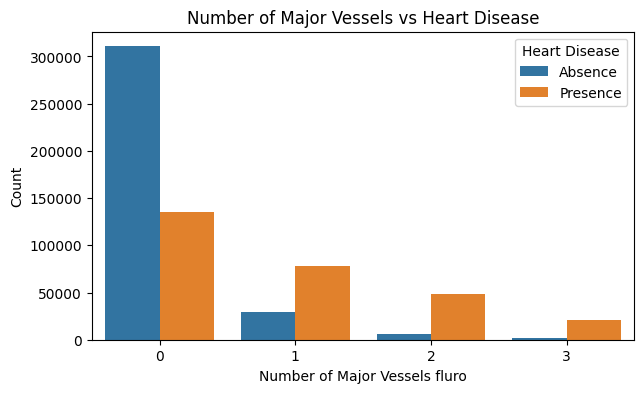

In [10]:
plt.figure(figsize=(7,4))
sns.countplot(
    x='Number of vessels fluro',
    hue='Heart Disease',
    data=train
)
plt.title('Number of Major Vessels vs Heart Disease')
plt.xlabel('Number of Major Vessels fluro')
plt.ylabel('Count')
plt.legend(title='Heart Disease')
plt.show()

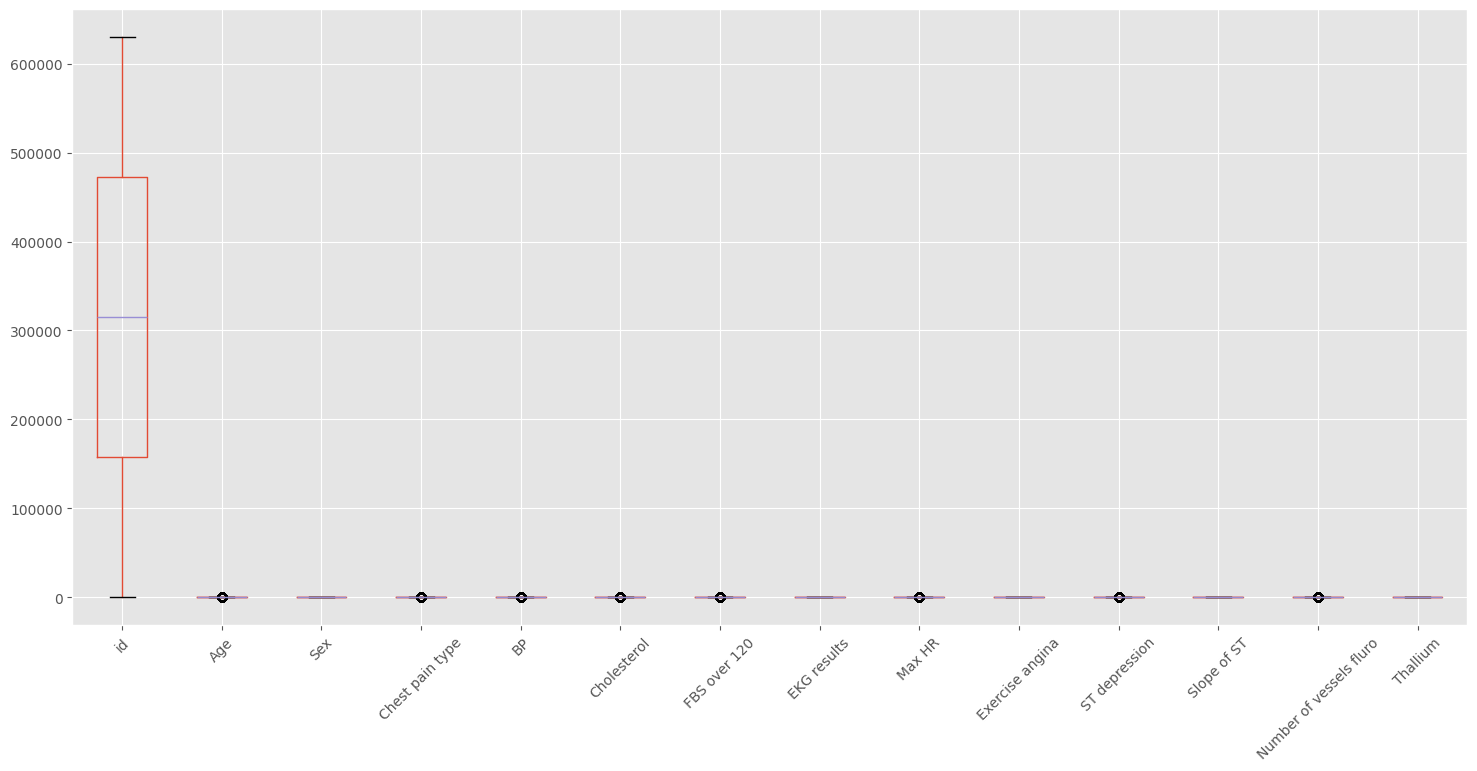

In [18]:
train.boxplot(figsize=(18,8))
plt.xticks(rotation=45)
plt.show()

Data Processing

In [19]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [22]:
X = train.drop(["id", "Heart Disease"], axis=1)
y = train["Heart Disease"]

In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train["Heart Disease"] = label_encoder.fit_transform(train["Heart Disease"])

In [24]:
train["Heart Disease"].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

In [25]:
X = train.drop(["id", "Heart Disease"], axis=1)
y = train["Heart Disease"]

X_test = test.drop("id", axis=1)

In [26]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [27]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train["Heart Disease"] = label_encoder.fit_transform(train["Heart Disease"])

In [28]:
train["Heart Disease"].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

In [29]:
X = train.drop(["id", "Heart Disease"], axis=1)
y = train["Heart Disease"]

X_test = test.drop("id", axis=1)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [33]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [34]:
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [35]:
y_pred = lr_model.predict(X_valid)

In [36]:
accuracy = accuracy_score(y_valid, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8846825396825397


In [37]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [38]:
cm = confusion_matrix(y_valid, y_pred)
print(cm)

[[62988  6521]
 [ 8009 48482]]


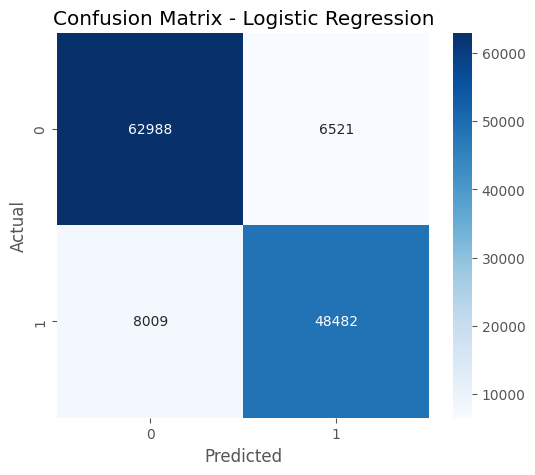

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [40]:
y_prob = lr_model.predict_proba(X_valid)[:, 1]

roc = roc_auc_score(y_valid, y_prob)

print("ROC-AUC:", roc)

ROC-AUC: 0.951546958953206


In [41]:
print("Accuracy:", accuracy)

print(classification_report(y_valid, y_pred))

print(confusion_matrix(y_valid, y_pred))

Accuracy: 0.8846825396825397
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000

[[62988  6521]
 [ 8009 48482]]


In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_dt))
print(classification_report(y_valid, y_pred_dt))

Accuracy: 0.8260396825396825
              precision    recall  f1-score   support

           0       0.84      0.84      0.84     69509
           1       0.80      0.81      0.81     56491

    accuracy                           0.83    126000
   macro avg       0.82      0.82      0.82    126000
weighted avg       0.83      0.83      0.83    126000



In [43]:
y_prob_dt = dt_model.predict_proba(X_valid)[:,1]

print("ROC-AUC:", roc_auc_score(y_valid, y_prob_dt))

ROC-AUC: 0.8243707434012881


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)

print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print(classification_report(y_valid, y_pred_rf))

Accuracy: 0.8821269841269841
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69509
           1       0.87      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [45]:
y_prob_rf = rf_model.predict_proba(X_valid)[:,1]

print("ROC-AUC:", roc_auc_score(y_valid, y_prob_rf))

ROC-AUC: 0.9482432269090849


In [46]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

In [47]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

In [48]:
Dense(64)

<Dense name=dense_3, built=False>

In [49]:
activation="relu"

In [50]:
Dropout(0.3)

<Dropout name=dropout_2, built=True>

In [51]:
Dense(1, activation="sigmoid")

<Dense name=dense_4, built=False>

In [52]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [53]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [54]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8775 - loss: 0.2986 - val_accuracy: 0.8865 - val_loss: 0.2741
Epoch 2/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8837 - loss: 0.2858 - val_accuracy: 0.8869 - val_loss: 0.2737
Epoch 3/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8843 - loss: 0.2843 - val_accuracy: 0.8868 - val_loss: 0.2735
Epoch 4/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8843 - loss: 0.2833 - val_accuracy: 0.8868 - val_loss: 0.2733
Epoch 5/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8843 - loss: 0.2834 - val_accuracy: 0.8867 - val_loss: 0.2732
Epoch 6/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8847 - loss: 0.2833 - val_accuracy: 0.8867 - val_loss: 0.2734
Epoch 7/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8844 - loss: 0.2828 - val_accuracy: 0.8867 - val_loss: 0.2731
Epoch 8/50
1969/1969 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8845 - loss: 0.2825 

In [55]:
model.evaluate(X_valid, y_valid)


3938/3938 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8872 - loss: 0.2728


[0.2728433907032013, 0.8872222304344177]

In [56]:
y_prob_nn = model.predict(X_valid)

y_pred_nn = (y_prob_nn > 0.5).astype(int)

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [57]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_valid, y_pred_nn))

Accuracy: 0.8872222222222222


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred_nn))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [59]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_valid, y_pred_nn))

[[63079  6430]
 [ 7780 48711]]


In [60]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_valid, y_prob_nn))

ROC-AUC: 0.953686600135183


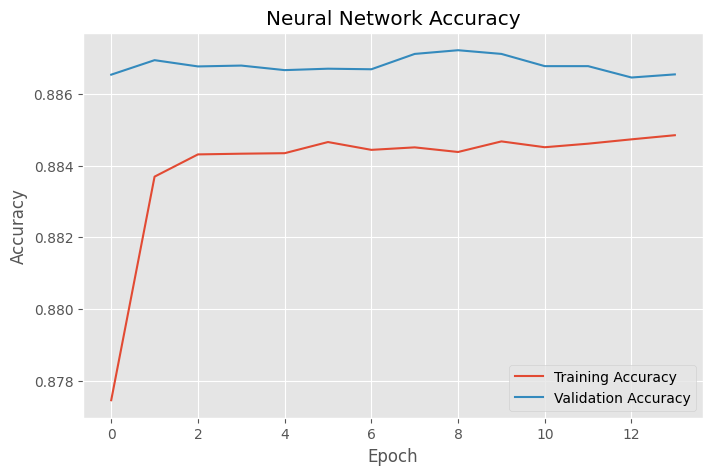

In [61]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Neural Network Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

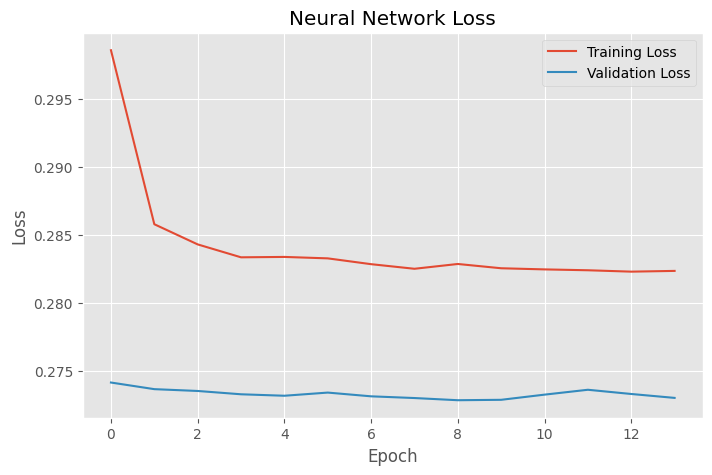

In [62]:
# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Neural Network Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [64]:
print("Random Forest Accuracy:", accuracy_score(y_valid, y_pred_rf))

Random Forest Accuracy: 0.8821269841269841


In [65]:
lr_accuracy = accuracy_score(y_valid, y_pred)
rf_accuracy = accuracy_score(y_valid, y_pred_rf)
nn_accuracy = accuracy_score(y_valid, y_pred_nn)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        nn_accuracy
    ],
    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob),
        roc_auc_score(y_valid, y_prob_rf),
        roc_auc_score(y_valid, y_prob_nn)
    ]
})

print(results)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression  0.884683  0.951547
1        Random Forest  0.882127  0.948243
2       Neural Network  0.887222  0.953687


In [66]:
model.save("heart_disease_model.keras")

In [68]:
test_predictions = model.predict(X_test_scaled)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 7s 740us/step


In [70]:
test_predictions = (test_predictions > 0.5).astype(int)

In [71]:
import numpy as np
import pandas as pd

submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": np.where(
        test_predictions.flatten() == 1,
        "Presence",
        "Absence"
    )
})

In [72]:
submission.head()

,id,Heart Disease
0,630000,Presence
1,630001,Absence
2,630002,Presence
3,630003,Absence
4,630004,Absence


In [73]:
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")


submission.csv created successfully!


In [74]:
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!


In [75]:
submission.head(10)

,id,Heart Disease
0,630000,Presence
1,630001,Absence
2,630002,Presence
3,630003,Absence
4,630004,Absence
5,630005,Presence
6,630006,Absence
7,630007,Presence
8,630008,Presence
9,630009,Absence


In [76]:
submission.shape

(270000, 2)

In [77]:
import os

print(os.getcwd())

c:\kaggle competition


In [78]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [1]:
from tensorflow.keras.models import load_model

model = load_model("heart_disease_model.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
import joblib

scaler = joblib.load("scaler.pkl")

In [4]:
import pandas as pd

test = pd.read_csv("test.csv")

In [5]:
X_test = test.drop(columns=["id"])

In [6]:
X_test_scaled = scaler.transform(X_test)

In [7]:
test_predictions = model.predict(X_test_scaled)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 7s 829us/step


In [8]:
print(test_predictions[:10])

[[0.96648437]
 [0.00243948]
 [0.9954518 ]
 [0.00387892]
 [0.34626335]
 [0.9891035 ]
 [0.01481285]
 [0.63323206]
 [0.9944329 ]
 [0.01005972]]


In [9]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": test_predictions.flatten()
})

submission.to_csv("submissionn.csv", index=False)

print("submission.csv created successfully!")

submission.csv created successfully!
